# Handwritten Character Recognition

## CodeAlpha Machine Learning Internship — Task 3

### Objective
Build a Convolutional Neural Network (CNN) to recognize handwritten digits using the MNIST dataset.

### Technologies
- Python
- TensorFlow / Keras
- NumPy
- Matplotlib
- Scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully! ✅")

TensorFlow version: 2.20.0
Libraries imported successfully! ✅


In [2]:
# Load the MNIST handwritten digit dataset

from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Dataset loaded successfully! ✅")
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully! ✅
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


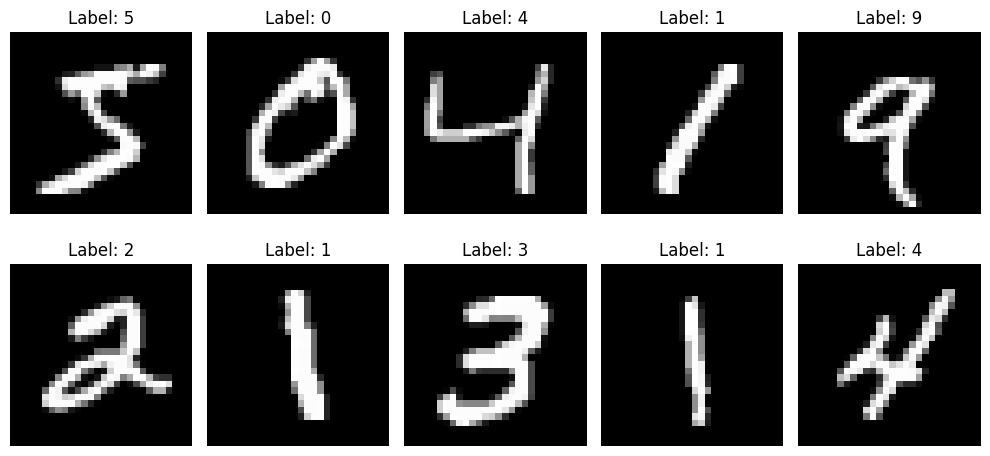

In [3]:
# Display sample handwritten digits

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# Normalize pixel values

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension
# CNN expects: (samples, height, width, channels)

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Preprocessing completed! ✅")
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Pixel range:", X_train.min(), "to", X_train.max())

Preprocessing completed! ✅
Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)
Pixel range: 0.0 to 1.0


In [5]:
# Check distribution of handwritten digits

unique, counts = np.unique(y_train, return_counts=True)

print("Digit distribution:")
for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} images")

Digit distribution:
Digit 0: 5923 images
Digit 1: 6742 images
Digit 2: 5958 images
Digit 3: 6131 images
Digit 4: 5842 images
Digit 5: 5421 images
Digit 6: 5918 images
Digit 7: 6265 images
Digit 8: 5851 images
Digit 9: 5949 images


In [6]:
# Build the CNN model

model = models.Sequential([

    # Convolutional layer
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    # Reduce spatial dimensions
    layers.MaxPooling2D((2, 2)),

    # Second convolutional layer
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    # Convert feature maps to a single vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Output layer: 10 digits (0–9)
    layers.Dense(10, activation="softmax")
])

print("CNN model created successfully! ✅")

CNN model created successfully! ✅


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compile the CNN

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully! ✅")

Model compiled successfully! ✅


In [9]:
# Train the CNN model

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("Training completed successfully! ✅")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 102ms/step - accuracy: 0.9339 - loss: 0.2245 - val_accuracy: 0.9775 - val_loss: 0.0750
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 98ms/step - accuracy: 0.9812 - loss: 0.0606 - val_accuracy: 0.9845 - val_loss: 0.0543
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.9859 - loss: 0.0430 - val_accuracy: 0.9865 - val_loss: 0.0454
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9901 - loss: 0.0319 - val_accuracy: 0.9885 - val_loss: 0.0374
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 97ms/step - accuracy: 0.9922 - loss: 0.0253 - val_accuracy: 0.9898 - val_loss: 0.0361
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9933 - loss: 0.0207 - val_accuracy: 0.9845 - val_loss: 0.0546
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.9952 - loss: 0.0153 - val_accuracy: 0.9908 - val_loss: 0.0363
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9959 - loss: 0.0127 -

In [11]:
# Evaluate the model on unseen test data

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4%}")

Test Loss: 0.0356
Test Accuracy: 98.8900%


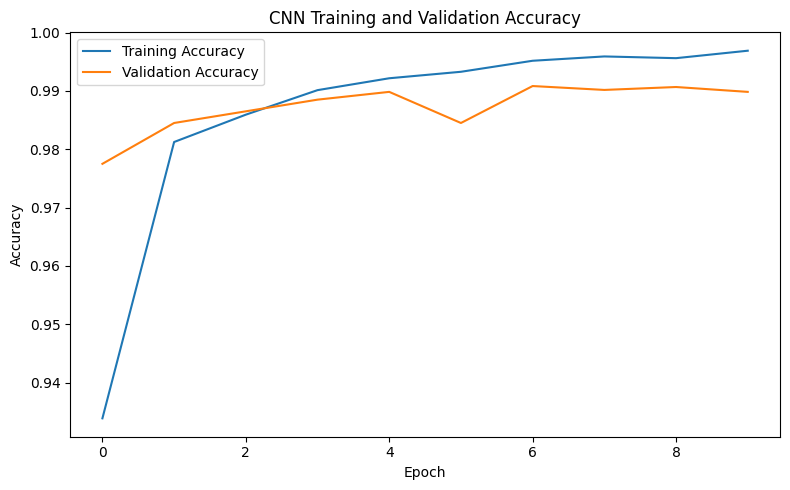

In [12]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

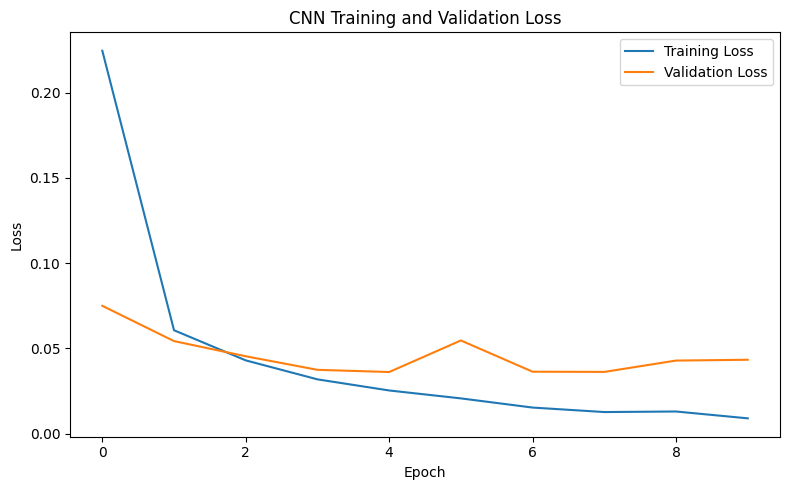

In [13]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

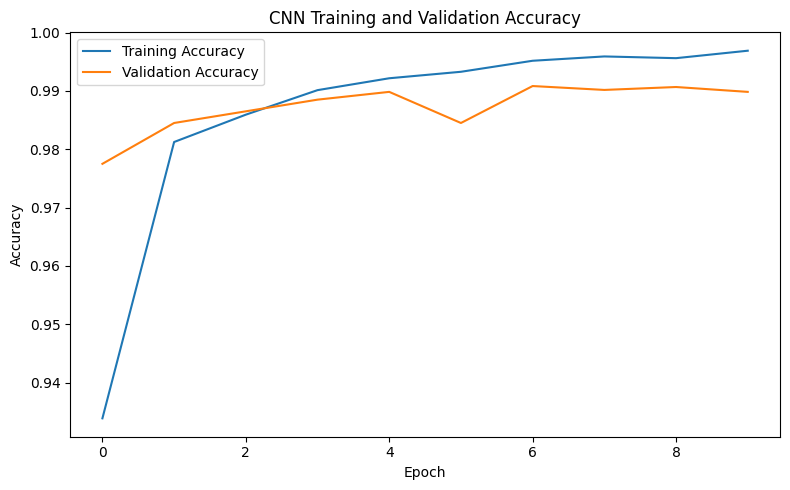

In [14]:
# Save accuracy graph

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("accuracy_loss_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

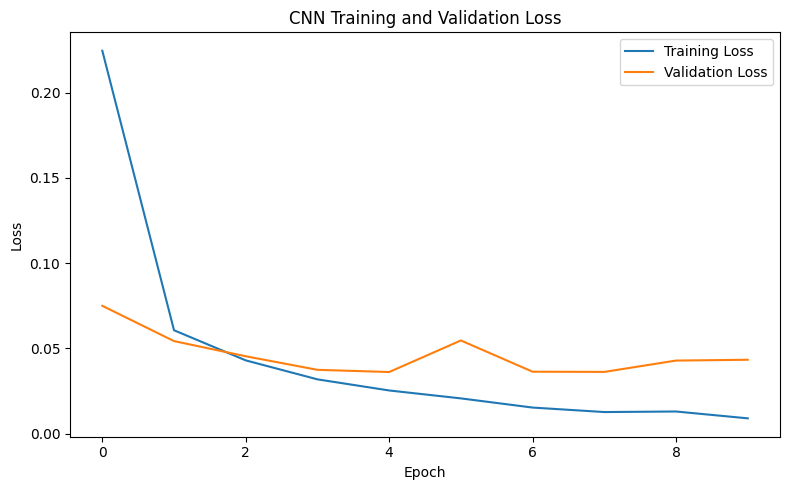

In [15]:
# Save loss graph

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("accuracy_loss_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# Generate predictions for the test set

y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions generated successfully! ✅")
print("Number of predictions:", len(y_pred))

Predictions generated successfully! ✅
Number of predictions: 10000


In [17]:
# Classification report

print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

Classification Report
              precision    recall  f1-score   support

           0     0.9959    0.9888    0.9923       980
           1     0.9930    0.9974    0.9952      1135
           2     0.9971    0.9893    0.9932      1032
           3     0.9872    0.9950    0.9911      1010
           4     0.9959    0.9796    0.9877       982
           5     0.9756    0.9877    0.9816       892
           6     0.9905    0.9843    0.9874       958
           7     0.9827    0.9932    0.9879      1028
           8     0.9969    0.9795    0.9881       974
           9     0.9737    0.9921    0.9828      1009

    accuracy                         0.9889     10000
   macro avg     0.9888    0.9887    0.9887     10000
weighted avg     0.9890    0.9889    0.9889     10000



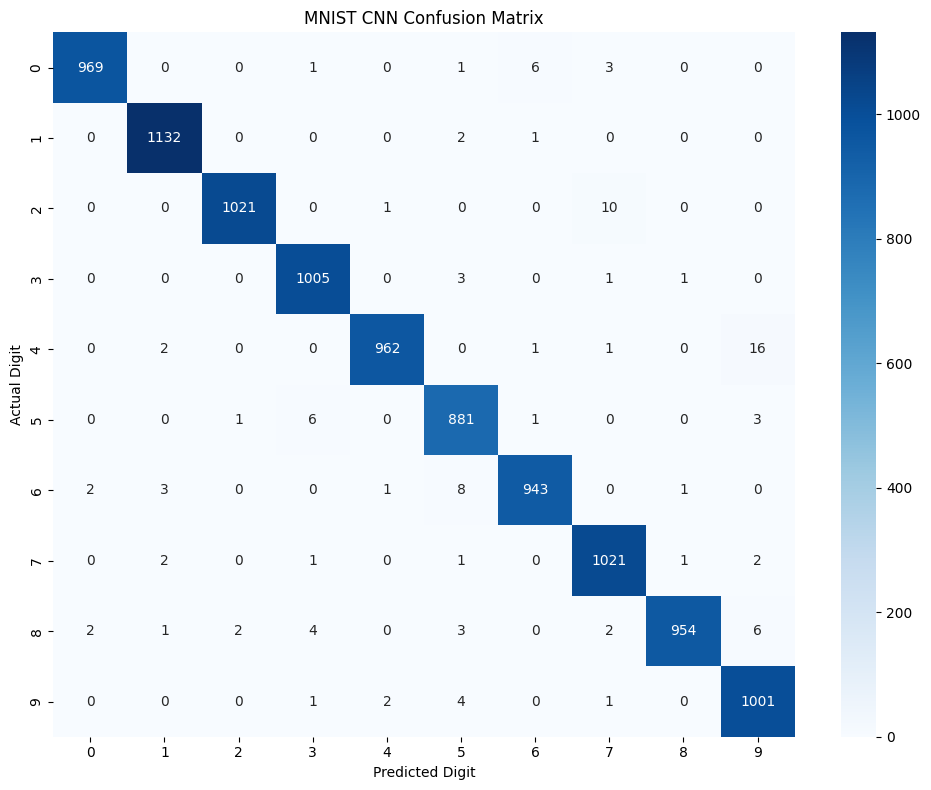

In [18]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("MNIST CNN Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.tight_layout()
plt.show()

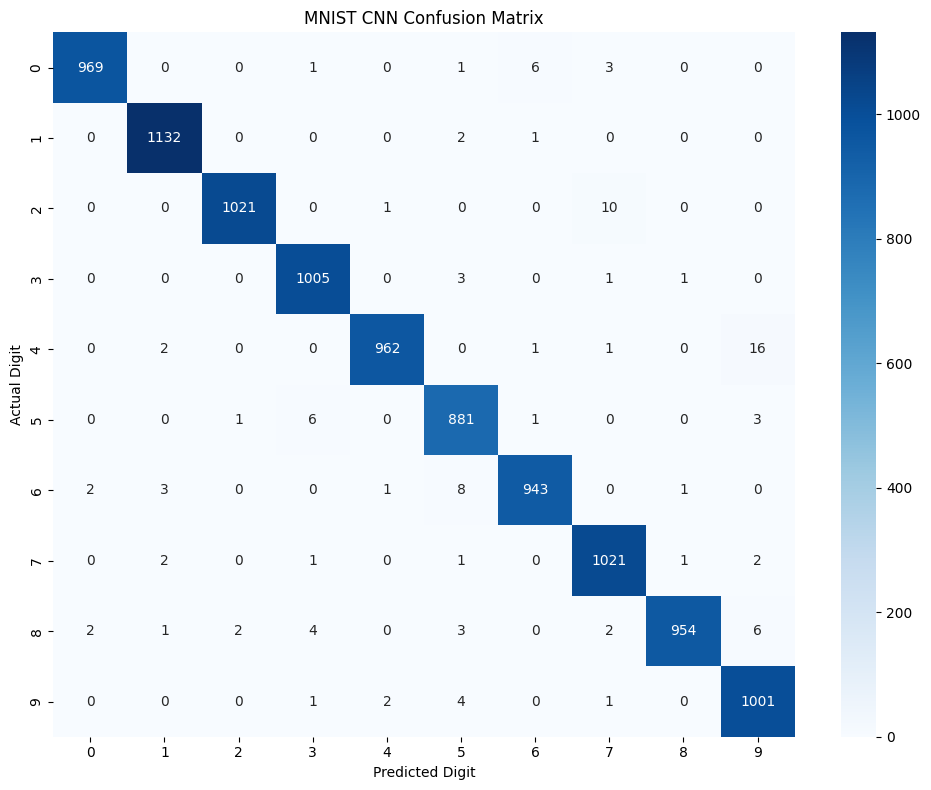

In [19]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("MNIST CNN Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

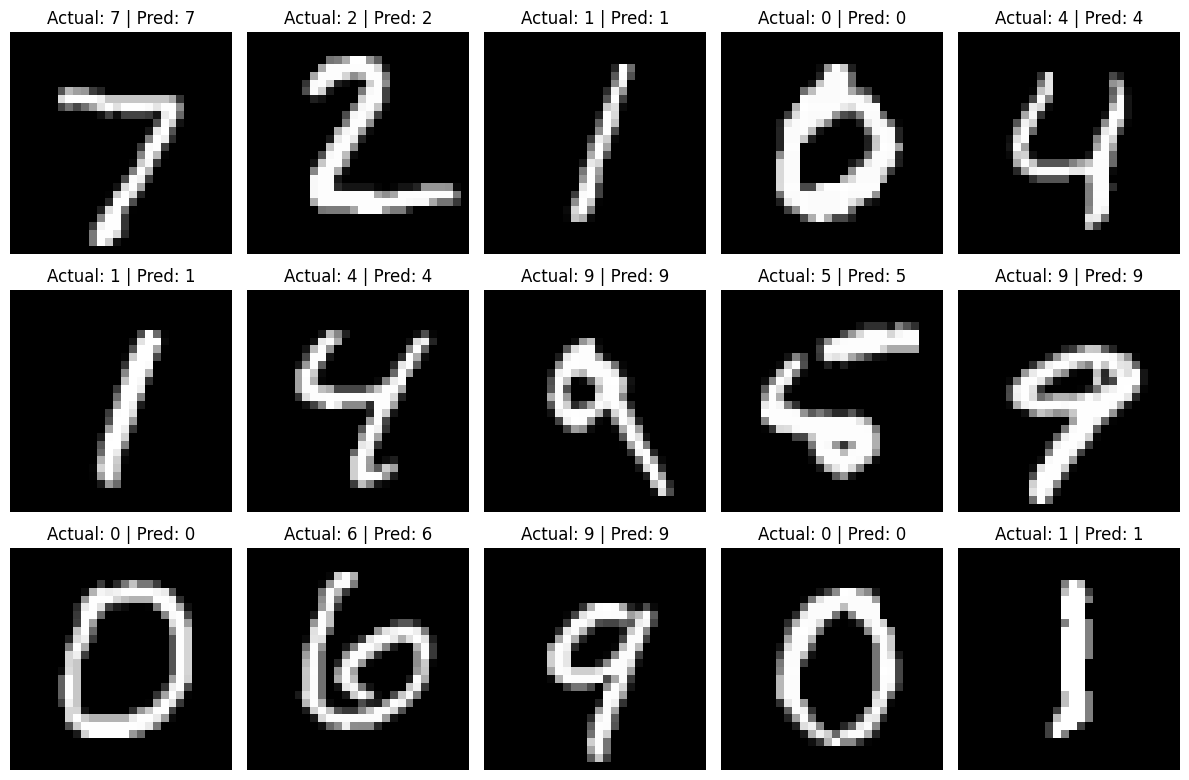

In [20]:
# Display sample predictions

plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    actual = y_test[i]
    predicted = y_pred[i]

    plt.title(f"Actual: {actual} | Pred: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Save the trained CNN model

model.save("handwritten_digit_cnn.keras")

print("Model saved successfully! ✅")

Model saved successfully! ✅


In [22]:
import os

print("Saved model:")
print(os.path.getsize("handwritten_digit_cnn.keras"), "bytes")

Saved model:
2737871 bytes
